In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Set random seed for reproducibility
np.random.seed(42)

# Create date range
dates = pd.date_range(start="2024-01-01", end="2024-12-31", freq="D")

# Categories
categories = ["Food", "Travel", "Shopping", "Bills", "Entertainment"]

# Payment modes
payment_modes = ["Cash", "UPI", "Card"]

# Generate synthetic dataset
data = {
    "Date": np.random.choice(dates, 300),
    "Category": np.random.choice(categories, 300),
    "Amount": np.random.randint(100, 5000, 300),
    "Payment Mode": np.random.choice(payment_modes, 300),
    "Description": "Expense"
}

df = pd.DataFrame(data)
df.head()


,Date,Category,Amount,Payment Mode,Description
0,2024-04-12,Food,3023,UPI,Expense
1,2024-12-14,Entertainment,2314,Cash,Expense
2,2024-09-27,Bills,4286,Card,Expense
3,2024-04-16,Shopping,813,UPI,Expense
4,2024-03-12,Food,3702,UPI,Expense


In [16]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          300 non-null    datetime64[us]
 1   Category      300 non-null    str           
 2   Amount        300 non-null    int32         
 3   Payment Mode  300 non-null    str           
 4   Description   300 non-null    str           
dtypes: datetime64[us](1), int32(1), str(3)
memory usage: 10.7 KB


(300, 5)

In [17]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.head()


,Date,Category,Amount,Payment Mode,Description,Month,Year
0,2024-04-12,Food,3023,UPI,Expense,4,2024
1,2024-12-14,Entertainment,2314,Cash,Expense,12,2024
2,2024-09-27,Bills,4286,Card,Expense,9,2024
3,2024-04-16,Shopping,813,UPI,Expense,4,2024
4,2024-03-12,Food,3702,UPI,Expense,3,2024


In [18]:
monthly_expense = df.groupby('Month')['Amount'].sum()

monthly_expense


Month
1     43527
2     74587
3     41762
4     73542
5     92325
6     60273
7     64291
8     99724
9     71253
10    52919
11    52802
12    80262
Name: Amount, dtype: int32

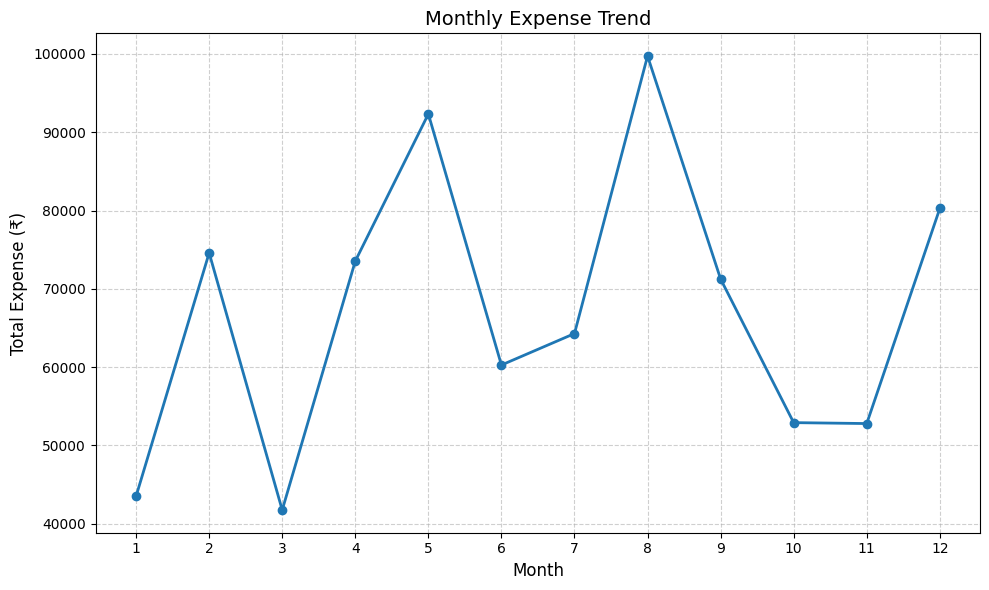

In [24]:
plt.figure(figsize=(10,6))

monthly_expense_sorted = monthly_expense.sort_index()

plt.plot(monthly_expense_sorted.index,
         monthly_expense_sorted.values,
         marker='o',
         linewidth=2)

plt.title("Monthly Expense Trend", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Expense (₹)", fontsize=12)

plt.xticks(range(1,13))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
category_expense = df.groupby('Category')['Amount'].sum()

category_expense


Category
Bills            149043
Entertainment    195859
Food             159045
Shopping         138574
Travel           164746
Name: Amount, dtype: int32

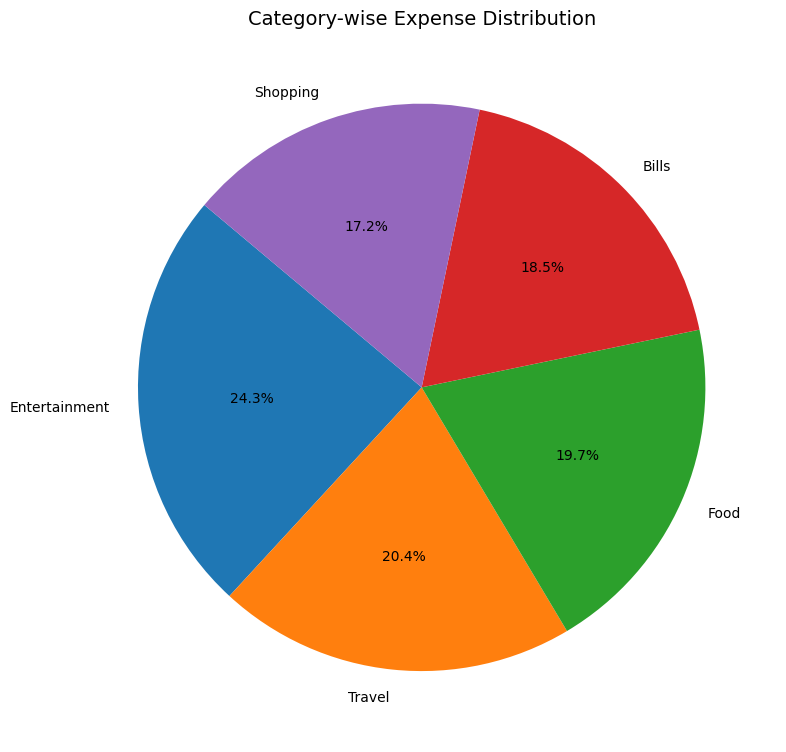

In [25]:
plt.figure(figsize=(8,8))

category_expense_sorted = category_expense.sort_values(ascending=False)

plt.pie(category_expense_sorted,
        labels=category_expense_sorted.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title("Category-wise Expense Distribution", fontsize=14)

plt.tight_layout()
plt.show()


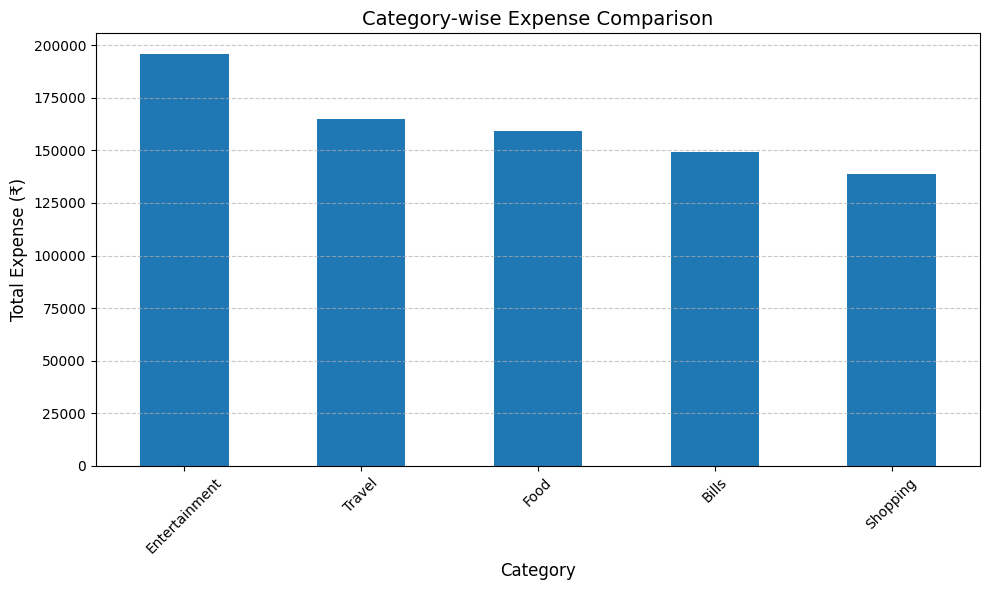

In [23]:
plt.figure(figsize=(10,6))

# Sort values for better visual impact
category_expense_sorted = category_expense.sort_values(ascending=False)

category_expense_sorted.plot(kind='bar')

plt.title("Category-wise Expense Comparison", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Expense (₹)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
